# Лабораторная работа №1: Задания на дополнительные баллы
### Реализация продвинутых механизмов однослойного перцептрона

**Цели ноутбука:**
1. Тестирование перцептрона на кастомных нелинейных геометрических структурах (XOR, Окружность).
2. Анализ работы альтернативной функции потерь Hinge Loss.
3. Оценка влияния L2-регуляризации на устойчивость весов.
4. Расчет расширенных метрик (Precision, Recall, F1, ROC-AUC) и визуализация ошибок классификации.
5. Исследование метода оптимизации Momentum SGD.
6. Оценка качества посредством 5-Fold кросс-валидации и подбора гиперпараметров по сетке.

In [8]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.data_generator import CustomDataGenerator
from src.preprocessing import StandardScaler, train_test_split_stratified
from src.perceptron import Perceptron
from src.metrics import (
    precision_score, recall_score, f1_score,
    roc_curve_data, roc_auc_score, accuracy_score
)
from src.visualization import (
    plot_decision_boundary, plot_learning_curve,
    plot_roc_curve, plot_misclassified
)

## Задание 1. Собственный генератор данных и нелинейная разделимость

Сгенерируем три структуры данных:
1. Линейно разделимые гауссовы облака с небольшим шумом (5%).
2. Нелинейные данные (XOR).
3. Данные в форме кольца (Окружность).
Проверим применимость однослойного перцептрона к этим задачам.

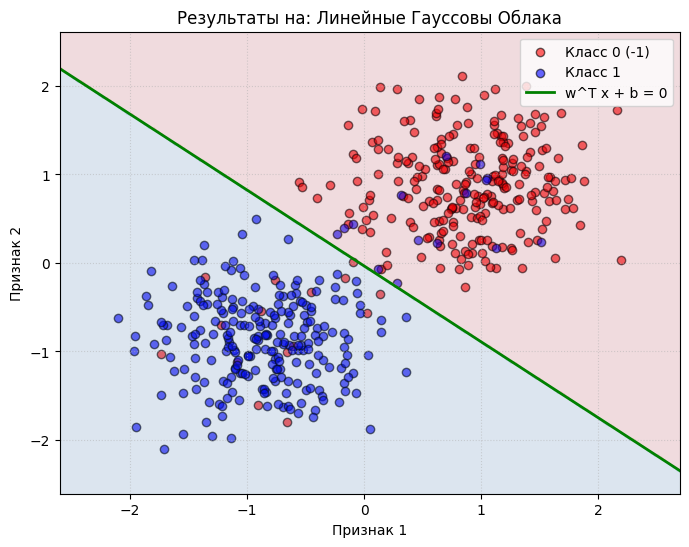

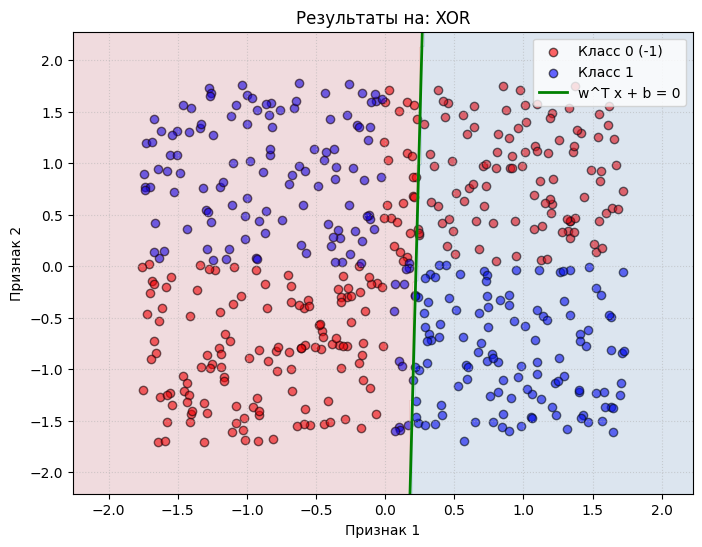

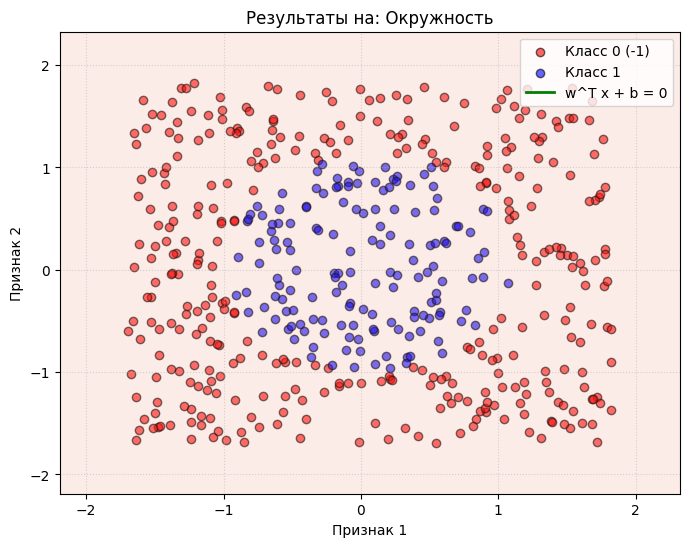

In [9]:
gen = CustomDataGenerator()

scenarios = {
    "Линейные Гауссовы Облака": gen.generate_linear_data(noise_prob=0.05),
    "XOR": gen.generate_xor_data(),
    "Окружность": gen.generate_circle_data()
}

for name, (X_raw, y_raw) in scenarios.items():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # Обучаем модель с базовыми параметрами
    model = Perceptron(input_size=2)
    model.fit(X_scaled, y_raw, X_scaled, y_raw, epochs=100, lr=0.1, batch_size=32)

    # Отрисовка границы решений
    plot_decision_boundary(X_scaled, y_raw, model, title=f"Результаты на: {name}")

## Задание 2. Hinge Loss и L2-регуляризация

### Часть A. Сравнение BCE и Hinge Loss
Исследуем сходимость и итоговое качество перцептрона при использовании бинарной кросс-энтропии и Hinge Loss на линейных данных.

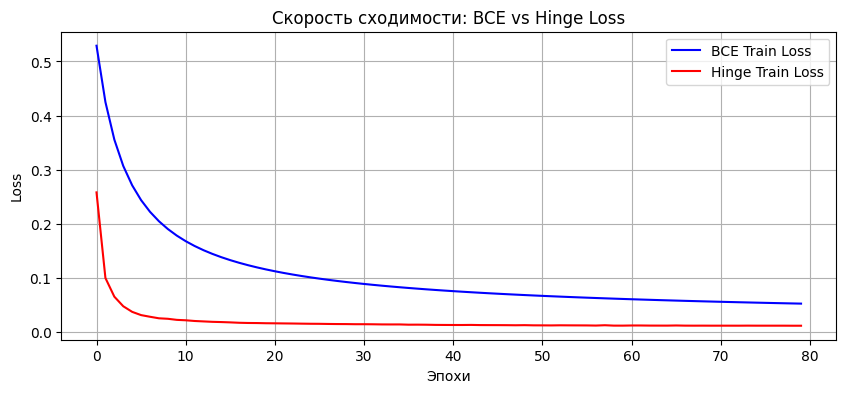

In [10]:
X_lin, y_lin = gen.generate_linear_data(n_samples=500, noise_prob=0.0)
X_train, X_test, y_train, y_test = train_test_split_stratified(X_lin, y_lin, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Обучение BCE
model_bce = Perceptron(input_size=2, loss_fn='bce')
hist_bce = model_bce.fit(X_train_s, y_train, X_test_s, y_test, epochs=80, lr=0.05, batch_size=32)

# Обучение Hinge
model_hinge = Perceptron(input_size=2, loss_fn='hinge')
hist_hinge = model_hinge.fit(X_train_s, y_train, X_test_s, y_test, epochs=80, lr=0.05, batch_size=32)

# Визуализация сходимости
plt.figure(figsize=(10, 4))
plt.plot(hist_bce['train_loss'], label='BCE Train Loss', color='blue')
plt.plot(hist_hinge['train_loss'], label='Hinge Train Loss', color='red')
plt.title("Скорость сходимости: BCE vs Hinge Loss")
plt.xlabel("Эпохи")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Часть Б. L2-регуляризация
Оценим влияние различных коэффициентов регуляризации $\lambda$ на норму весов перцептрона.

In [4]:
lambdas = [0.0, 0.001, 0.05, 0.5]

for lam in lambdas:
    model_l2 = Perceptron(input_size=2, loss_fn='bce', l2_lambda=lam)
    model_l2.fit(X_train_s, y_train, X_test_s, y_test, epochs=80, lr=0.1, batch_size=32)

    w_norm = np.linalg.norm(model_l2.w)
    print(f"Коэффициент lambda = {lam:<5} | Норма вектора весов (||w||_2): {w_norm:.6f}")

Коэффициент lambda = 0.0   | Норма вектора весов (||w||_2): 4.183434
Коэффициент lambda = 0.001 | Норма вектора весов (||w||_2): 4.021673
Коэффициент lambda = 0.05  | Норма вектора весов (||w||_2): 1.913836
Коэффициент lambda = 0.5   | Норма вектора весов (||w||_2): 0.674292


## Задание 3. Метрики качества и анализ ошибок

Рассчитаем расширенные метрики качества на тестовом множестве зашумленного линейного датасета и построим ROC-кривую, а также подсветим ошибочные точки на графике.

Precision: 0.8289
Recall:    0.8750
F1-Score:  0.8514


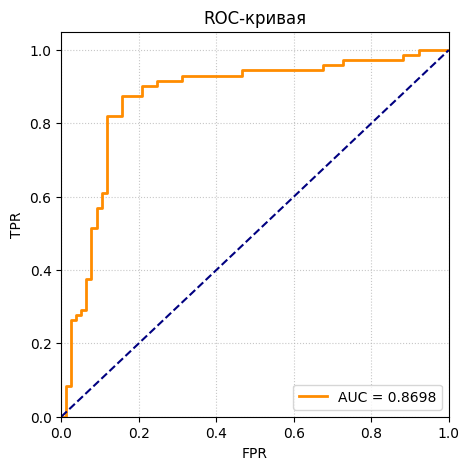

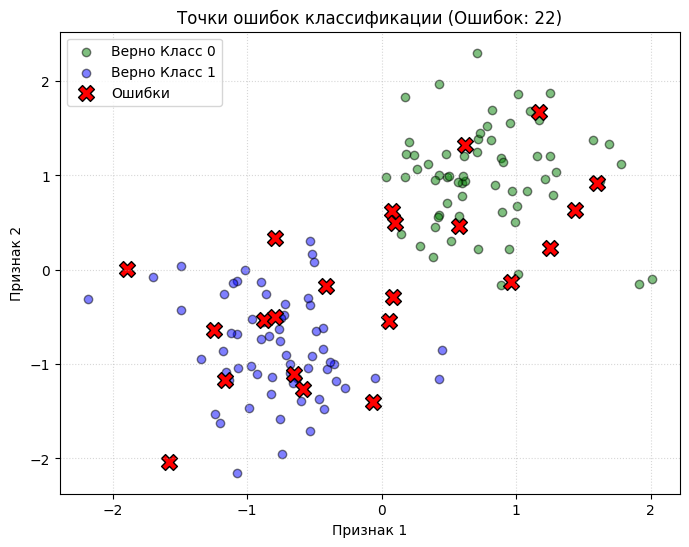

In [11]:
np.random.seed(42)
X_noisy, y_noisy = gen.generate_linear_data(noise_prob=0.15)
X_tr, X_te, y_tr, y_te = train_test_split_stratified(X_noisy, y_noisy, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

model_eval = Perceptron(input_size=2, loss_fn='bce')
model_eval.fit(X_tr_s, y_tr, X_te_s, y_te, epochs=100, lr=0.1, batch_size=32)

# Предсказания
preds = model_eval.predict(X_te_s)
probs = model_eval.forward(X_te_s)

# Вычисление метрик
print(f"Precision: {precision_score(y_te, preds):.4f}")
print(f"Recall:    {recall_score(y_te, preds):.4f}")
print(f"F1-Score:  {f1_score(y_te, preds):.4f}")

# Расчет ROC-AUC и построение графика
fpr, tpr = roc_curve_data(y_te, probs)
auc_val = roc_auc_score(fpr, tpr)
plot_roc_curve(fpr, tpr, auc_val)

# Визуализация распределения ошибок классификации
plot_misclassified(X_te_s, y_te, preds)

## Задание 4. Оптимизатор Momentum SGD

Сравним сходимость стандартного градиентного спуска с методом импульса (Momentum) при значениях коэффициента затухания $\beta \in \{0.5, 0.9, 0.99\}$.

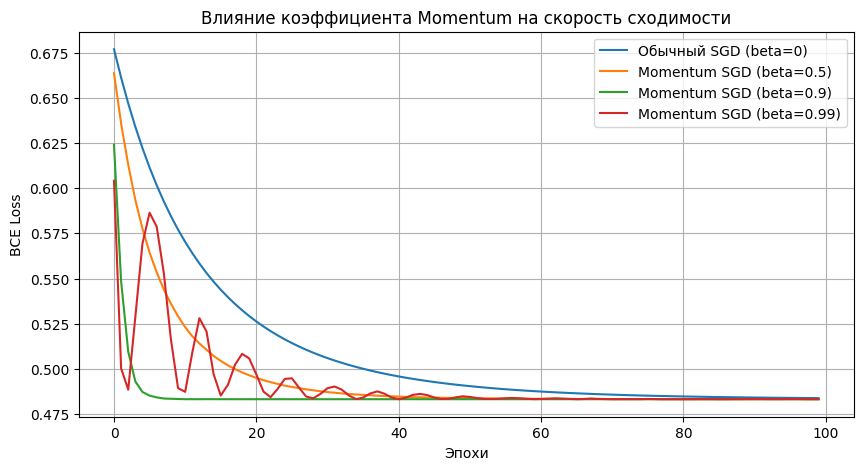

In [12]:
betas = [0.0, 0.5, 0.9, 0.99]
plt.figure(figsize=(10, 5))

for b in betas:
    np.random.seed(42)
    model_mom = Perceptron(input_size=2)
    # Медленный шаг lr для наглядности преимуществ Momentum
    hist_mom = model_mom.fit(X_tr_s, y_tr, X_te_s, y_te, epochs=100, lr=0.01, batch_size=32, momentum_beta=b)

    lbl = "Обычный SGD (beta=0)" if b == 0.0 else f"Momentum SGD (beta={b})"
    plt.plot(hist_mom['train_loss'], label=lbl)

plt.title("Влияние коэффициента Momentum на скорость сходимости")
plt.xlabel("Эпохи")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True)
plt.show()

## Задание 5. Кросс-валидация и подбор гиперпараметров

Спроектируем 5-кратную перекрестную валидацию (5-Fold CV) для автоматического поиска лучшего сочетания `learning rate` ($\eta$) и `batch_size`.

In [13]:
from src.perceptron import Perceptron
from src.preprocessing import StandardScaler
from src.metrics import accuracy_score

def k_fold_cross_validation(X, y, k=5, epochs=50, lr=0.1, batch_size=32):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    scores = []
    for fold_idx in range(k):
        val_indices = folds[fold_idx]
        train_indices = np.hstack([folds[i] for i in range(k) if i != fold_idx])

        X_tr_fold, y_tr_fold = X[train_indices], y[train_indices]
        X_val_fold, y_val_fold = X[val_indices], y[val_indices]

        # Корректное масштабирование внутри текущей итерации
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_fold)
        X_val_scaled = scaler.transform(X_val_fold)

        model = Perceptron(input_size=X.shape[1])
        model.fit(X_tr_scaled, y_tr_fold, X_val_scaled, y_val_fold, epochs=epochs, lr=lr, batch_size=batch_size)

        preds = model.predict(X_val_scaled)
        scores.append(accuracy_score(y_val_fold.reshape(-1, 1), preds))

    return np.mean(scores), np.std(scores)

# Поиск по сетке параметров
lrs = [0.005, 0.05, 0.2]
batch_sizes = [16, 32, 64]

best_score = -1.0
best_params = {}

print(f"{'lr':<10} | {'batch_size':<10} | {'Mean Acc':<12} | {'Std Dev':<10}")
print("-" * 51)

for lr in lrs:
    for bs in batch_sizes:
        mean_acc, std_acc = k_fold_cross_validation(X_noisy, y_noisy, k=5, epochs=50, lr=lr, batch_size=bs)
        print(f"{lr:<10} | {bs:<10} | {mean_acc:<12.4f} | {std_acc:<10.4f}")

        if mean_acc > best_score:
            best_score = mean_acc
            best_params = {"lr": lr, "batch_size": bs}

print("\n" + "="*50)
print(f"Лучшие параметры по результатам поиска: {best_params}")
print(f"Точность на кросс-валидации: {best_score:.4f}")
print("="*50)

lr         | batch_size | Mean Acc     | Std Dev   
---------------------------------------------------
0.005      | 16         | 0.8380       | 0.0279    
0.005      | 32         | 0.8360       | 0.0393    
0.005      | 64         | 0.8380       | 0.0349    
0.05       | 16         | 0.8300       | 0.0303    
0.05       | 32         | 0.8380       | 0.0387    
0.05       | 64         | 0.8340       | 0.0372    
0.2        | 16         | 0.8380       | 0.0271    
0.2        | 32         | 0.8320       | 0.0214    
0.2        | 64         | 0.8380       | 0.0331    

Лучшие параметры по результатам поиска: {'lr': 0.005, 'batch_size': 64}
Точность на кросс-валидации: 0.8380
